# Problem Statement 6: Hyperparameter Tuning & Regularization

This notebook tunes a regularized recurrent classifier on MNIST and compares the effect of learning rate, batch size, hidden units, number of layers, dropout, optimizer choice, gradient clipping, early stopping, scheduling, and normalization.

In [1]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from IPython.display import display
from torch.utils.data import DataLoader, random_split

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset_full = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True,
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True,
)

train_size = 10000
val_size = 2000
rest_size = len(train_dataset_full) - train_size - val_size
train_dataset, val_dataset, _ = random_split(
    train_dataset_full,
    [train_size, val_size, rest_size],
    generator=torch.Generator().manual_seed(seed),
)


def build_loaders(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader


print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:14<00:00, 673kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:08<00:00, 184kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.10MB/s]

Train samples: 10000
Validation samples: 2000
Test samples: 10000


In [3]:
class RegularizedLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size=28,
        hidden_units=128,
        num_layers=2,
        num_classes=10,
        dropout_rate=0.2,
        use_batch_norm=False,
        use_layer_norm=True,
    ):
        super().__init__()
        self.hidden_units = hidden_units
        self.num_layers = num_layers

        lstm_dropout = dropout_rate if num_layers > 1 else 0.0
        self.input_dropout = nn.Dropout(dropout_rate)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_units,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )
        self.batch_norm = nn.BatchNorm1d(hidden_units) if use_batch_norm else nn.Identity()
        self.layer_norm = nn.LayerNorm(hidden_units) if use_layer_norm else nn.Identity()
        self.hidden_dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_units, hidden_units)
        self.fc2 = nn.Linear(hidden_units, num_classes)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.input_dropout(x)
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_units, device=x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_units, device=x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.layer_norm(out)
        out = self.batch_norm(out)
        out = self.activation(self.fc1(out))
        out = self.hidden_dropout(out)
        return self.fc2(out)

In [4]:
def make_optimizer(model, optimizer_name, learning_rate, weight_decay):
    if optimizer_name == "SGD":
        return optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
    if optimizer_name == "Adam":
        return optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    if optimizer_name == "RMSprop":
        return optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    if optimizer_name == "AdamW":
        return optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")


def train_one_epoch(model, train_loader, criterion, optimizer, gradient_clip):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.squeeze(1).permute(0, 2, 1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        if gradient_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)

        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.squeeze(1).permute(0, 2, 1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * labels.size(0)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total


def fit_model(config, max_epochs=3, patience=2, use_scheduler=True):
    train_loader, val_loader, test_loader = build_loaders(config["batch_size"])
    model = RegularizedLSTMClassifier(
        hidden_units=config["hidden_units"],
        num_layers=config["num_layers"],
        dropout_rate=config["dropout_rate"],
        use_batch_norm=config["use_batch_norm"],
        use_layer_norm=config["use_layer_norm"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(
        model,
        config["optimizer"],
        config["learning_rate"],
        config["weight_decay"],
    )
    scheduler = (
        optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)
        if use_scheduler
        else None
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    best_val_accuracy = 0.0
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            config["gradient_clip"],
        )
        val_loss, val_accuracy = evaluate(model, val_loader, criterion)

        if scheduler is not None:
            scheduler.step(val_loss)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_accuracy,
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
            }
        )

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)

    return {
        "config": config,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }

In [5]:
search_space = {
    "learning_rate": [0.1, 0.01, 0.001, 0.0001],
    "batch_size": [32, 64, 128, 256],
    "hidden_units": [32, 64, 128, 256, 512],
    "num_layers": [1, 2, 3, 4],
    "dropout_rate": [0.0, 0.2, 0.3, 0.5],
    "optimizer": ["SGD", "Adam", "RMSprop", "AdamW"],
    "gradient_clip": [None, 1.0, 5.0, 10.0],
}

candidate_configs = [
    {
        "learning_rate": 0.01,
        "batch_size": 64,
        "hidden_units": 128,
        "num_layers": 2,
        "dropout_rate": 0.2,
        "optimizer": "Adam",
        "gradient_clip": 1.0,
        "weight_decay": 1e-4,
        "use_batch_norm": True,
        "use_layer_norm": True,
    },
    {
        "learning_rate": 0.001,
        "batch_size": 128,
        "hidden_units": 256,
        "num_layers": 2,
        "dropout_rate": 0.3,
        "optimizer": "AdamW",
        "gradient_clip": 5.0,
        "weight_decay": 1e-4,
        "use_batch_norm": False,
        "use_layer_norm": True,
    },
    {
        "learning_rate": 0.0001,
        "batch_size": 64,
        "hidden_units": 128,
        "num_layers": 3,
        "dropout_rate": 0.2,
        "optimizer": "RMSprop",
        "gradient_clip": 1.0,
        "weight_decay": 1e-5,
        "use_batch_norm": False,
        "use_layer_norm": True,
    },
    {
        "learning_rate": 0.01,
        "batch_size": 256,
        "hidden_units": 64,
        "num_layers": 1,
        "dropout_rate": 0.0,
        "optimizer": "SGD",
        "gradient_clip": None,
        "weight_decay": 1e-4,
        "use_batch_norm": True,
        "use_layer_norm": False,
    },
    {
        "learning_rate": 0.001,
        "batch_size": 32,
        "hidden_units": 256,
        "num_layers": 4,
        "dropout_rate": 0.5,
        "optimizer": "AdamW",
        "gradient_clip": 10.0,
        "weight_decay": 1e-4,
        "use_batch_norm": False,
        "use_layer_norm": True,
    },
]

print("Search space loaded.")
print(f"Representative candidate configs: {len(candidate_configs)}")

Search space loaded.
Representative candidate configs: 5


In [6]:
results = []

for index, config in enumerate(candidate_configs, start=1):
    print(f"Running configuration {index}/{len(candidate_configs)}")
    print(config)
    result = fit_model(config, max_epochs=3, patience=2, use_scheduler=True)
    results.append(result)
    print(
        f"  Best epoch: {result['best_epoch']}, "
        f"Val acc: {result['best_val_accuracy']:.4f}, "
        f"Test acc: {result['test_accuracy']:.4f}"
    )
    print("-")

results_df = pd.DataFrame([
    {
        "run": index + 1,
        "learning_rate": result["config"]["learning_rate"],
        "batch_size": result["config"]["batch_size"],
        "hidden_units": result["config"]["hidden_units"],
        "num_layers": result["config"]["num_layers"],
        "dropout_rate": result["config"]["dropout_rate"],
        "optimizer": result["config"]["optimizer"],
        "gradient_clip": result["config"]["gradient_clip"],
        "weight_decay": result["config"]["weight_decay"],
        "best_epoch": result["best_epoch"],
        "val_loss": result["best_val_loss"],
        "val_accuracy": result["best_val_accuracy"],
        "test_loss": result["test_loss"],
        "test_accuracy": result["test_accuracy"],
    }
    for index, result in enumerate(results)
])

best_index = results_df["val_accuracy"].idxmax()
best_result = results[best_index]

print("Best configuration:")
print(best_result["config"])
print(f"Best validation accuracy: {best_result['best_val_accuracy']:.4f}")
print(f"Test accuracy: {best_result['test_accuracy']:.4f}")

display(results_df.sort_values("val_accuracy", ascending=False).reset_index(drop=True))

Running configuration 1/5
{'learning_rate': 0.01, 'batch_size': 64, 'hidden_units': 128, 'num_layers': 2, 'dropout_rate': 0.2, 'optimizer': 'Adam', 'gradient_clip': 1.0, 'weight_decay': 0.0001, 'use_batch_norm': True, 'use_layer_norm': True}
  Best epoch: 3, Val acc: 0.9505, Test acc: 0.9494
-
Running configuration 2/5
{'learning_rate': 0.001, 'batch_size': 128, 'hidden_units': 256, 'num_layers': 2, 'dropout_rate': 0.3, 'optimizer': 'AdamW', 'gradient_clip': 5.0, 'weight_decay': 0.0001, 'use_batch_norm': False, 'use_layer_norm': True}
  Best epoch: 3, Val acc: 0.9430, Test acc: 0.9447
-
Running configuration 3/5
{'learning_rate': 0.0001, 'batch_size': 64, 'hidden_units': 128, 'num_layers': 3, 'dropout_rate': 0.2, 'optimizer': 'RMSprop', 'gradient_clip': 1.0, 'weight_decay': 1e-05, 'use_batch_norm': False, 'use_layer_norm': True}
  Best epoch: 3, Val acc: 0.8740, Test acc: 0.8782
-
Running configuration 4/5
{'learning_rate': 0.01, 'batch_size': 256, 'hidden_units': 64, 'num_layers': 1, 

,run,learning_rate,batch_size,hidden_units,num_layers,dropout_rate,optimizer,gradient_clip,weight_decay,best_epoch,val_loss,val_accuracy,test_loss,test_accuracy
0,1,0.0100,64,128,2,0.2,Adam,1.0,0.00010,3,0.189037,0.9505,0.193637,0.9494
1,2,0.0010,128,256,2,0.3,AdamW,5.0,0.00010,3,0.188808,0.9430,0.197071,0.9447
2,5,0.0010,32,256,4,0.5,AdamW,10.0,0.00010,3,0.250951,0.9325,0.251498,0.9333
3,3,0.0001,64,128,3,0.2,RMSprop,1.0,0.00001,3,0.439911,0.8740,0.430851,0.8782
4,4,0.0100,256,64,1,0.0,SGD,NaN,0.00010,3,0.962884,0.6695,0.968060,0.6724


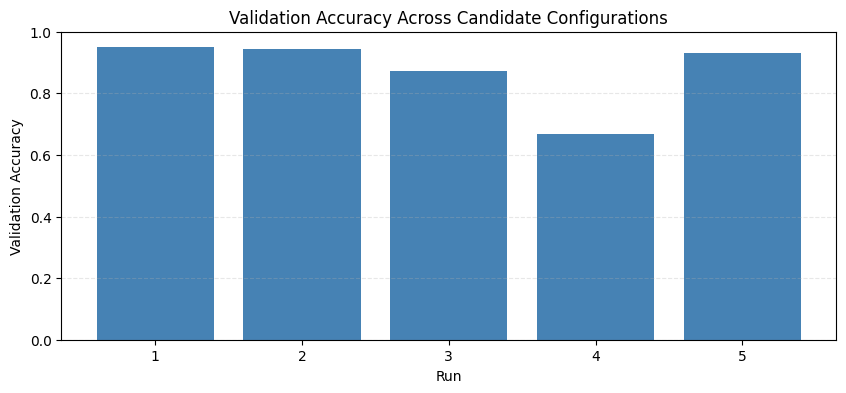

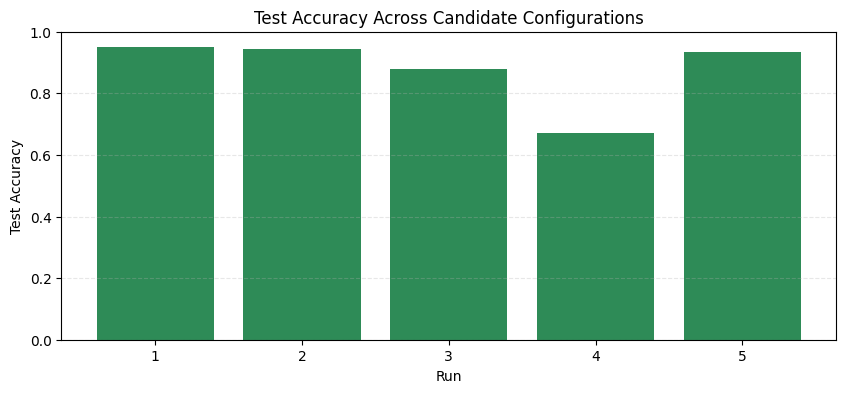

In [7]:
plt.figure(figsize=(10, 4))
plt.bar(results_df["run"].astype(str), results_df["val_accuracy"], color="steelblue")
plt.title("Validation Accuracy Across Candidate Configurations")
plt.xlabel("Run")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(results_df["run"].astype(str), results_df["test_accuracy"], color="seagreen")
plt.title("Test Accuracy Across Candidate Configurations")
plt.xlabel("Run")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()